<a href="https://colab.research.google.com/github/kolteharsh09-wq/restaurant-dashboard/blob/main/SkyCityDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("/content/sample_data/SkyCity Auckland Restaurants & Bars.csv")
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [3]:
df.shape

(1696, 30)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   object 
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   object 
 3   Segment                1696 non-null   object 
 4   Subregion              1696 non-null   object 
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  Self

In [5]:
df.isnull().sum()

,0
CuisineType,0
RestaurantID,0
RestaurantName,0
Segment,0
Subregion,0
GrowthFactor,0
AOV,0
MonthlyOrders,0
InStoreOrders,0
InStoreRevenue,0


In [6]:
df.fillna(0, inplace=True)

In [7]:
df.describe()

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,...,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,25848.500000,1.028255,38.516887,1190.527123,218.980542,8422.392730,471.906250,257.155071,242.485259,18170.030360,...,3.119363,755.783886,2257.321557,152.410425,89.105100,2139.315118,0.225654,0.486763,0.265242,0.247995
std,489.737345,0.022700,4.459408,422.334848,149.758619,5851.233352,171.781981,92.605301,129.950736,6959.241673,...,1.344848,541.323056,1618.692119,2340.125579,1271.832584,1875.802610,0.126977,0.067685,0.034294,0.094582
min,25001.000000,0.990000,29.790000,441.000000,13.000000,412.360000,142.000000,81.000000,60.000000,5050.950000,...,0.890000,53.400000,155.000000,-7787.110000,-4349.940000,-983.280000,0.030000,0.350000,0.200000,0.150000
25%,25424.750000,1.030000,34.787500,827.000000,101.000000,3904.342500,331.000000,179.750000,146.000000,12524.745000,...,1.770000,358.662500,1122.580000,-1291.512500,-718.617500,807.867500,0.110000,0.450000,0.250000,0.150000
50%,25848.500000,1.040000,38.340000,1182.000000,178.000000,6791.430000,456.000000,249.000000,212.000000,17548.980000,...,3.250000,601.800000,1785.720000,676.685000,369.665000,1742.945000,0.210000,0.500000,0.250000,0.200000
75%,26272.250000,1.050000,42.495000,1525.000000,307.000000,11550.755000,602.000000,326.250000,306.250000,23016.000000,...,4.130000,1005.030000,2848.090000,1581.570000,862.602500,2995.282500,0.320000,0.550000,0.300000,0.300000
max,26696.000000,1.050000,47.230000,2337.000000,819.000000,35356.230000,937.000000,466.000000,702.000000,43038.960000,...,5.310000,3653.280000,10474.680000,8275.570000,4514.880000,13222.100000,0.550000,0.600000,0.300000,0.450000


In [8]:
revenue = {
    "InStore": df["InStoreRevenue"].sum(),
    "UberEats": df["UberEatsRevenue"].sum(),
    "DoorDash": df["DoorDashRevenue"].sum(),
    "SelfDelivery": df["SelfDeliveryRevenue"].sum()
}

revenue

{'InStore': np.float64(14284378.07),
 'UberEats': np.float64(30816371.490000002),
 'DoorDash': np.float64(16789380.950000003),
 'SelfDelivery': np.float64(15849176.290000001)}

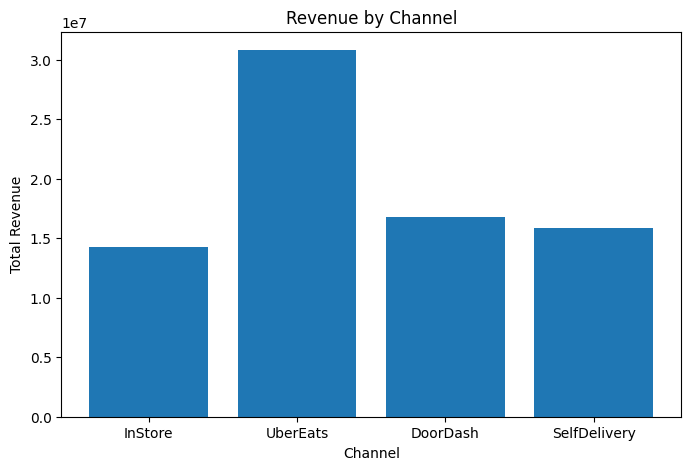

In [9]:
plt.figure(figsize=(8,5))

plt.bar(revenue.keys(), revenue.values())

plt.title("Revenue by Channel")

plt.xlabel("Channel")

plt.ylabel("Total Revenue")

plt.show()

In [10]:
profit = {
    "InStore": df["InStoreNetProfit"].sum(),
    "DoorDash": df["DoorDashNetProfit"].sum(),
    "SelfDelivery": df["SelfDeliveryNetProfit"].sum()
}

profit

{'InStore': np.float64(3828417.36),
 'DoorDash': np.float64(151122.25),
 'SelfDelivery': np.float64(3628278.4400000004)}

In [11]:
display(df['UberEatsNetProfit'].describe())

,UberEatsNetProfit
count,1696.000000
mean,152.410425
std,2340.125579
min,-7787.110000
25%,-1291.512500
50%,676.685000
75%,1581.570000
max,8275.570000


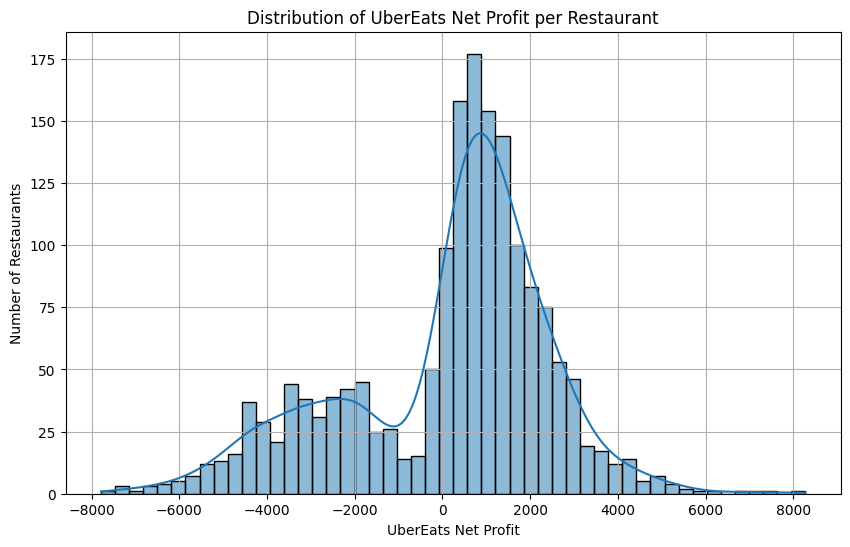

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['UberEatsNetProfit'], bins=50, kde=True)
plt.title('Distribution of UberEats Net Profit per Restaurant')
plt.xlabel('UberEats Net Profit')
plt.ylabel('Number of Restaurants')
plt.grid(True)
plt.show()

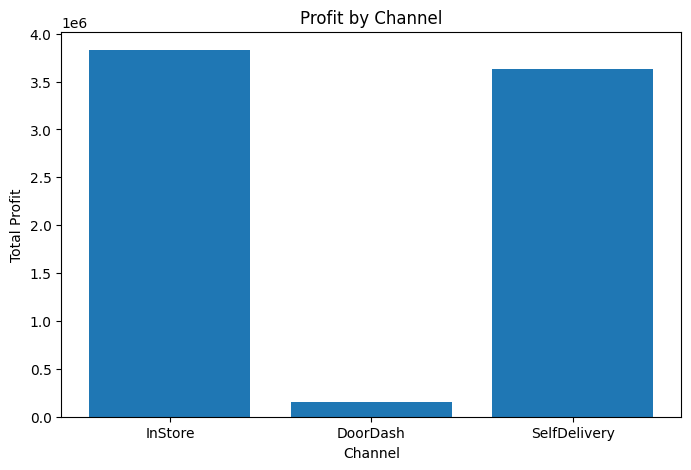

In [13]:
plt.figure(figsize=(8,5))

plt.bar(profit.keys(), profit.values())

plt.title("Profit by Channel")

plt.xlabel("Channel")

plt.ylabel("Total Profit")

plt.show()

In [14]:
profit["UberEats"] = df["UberEatsNetProfit"].sum()
profit

{'InStore': np.float64(3828417.36),
 'DoorDash': np.float64(151122.25),
 'SelfDelivery': np.float64(3628278.4400000004),
 'UberEats': np.float64(258488.08000000002)}

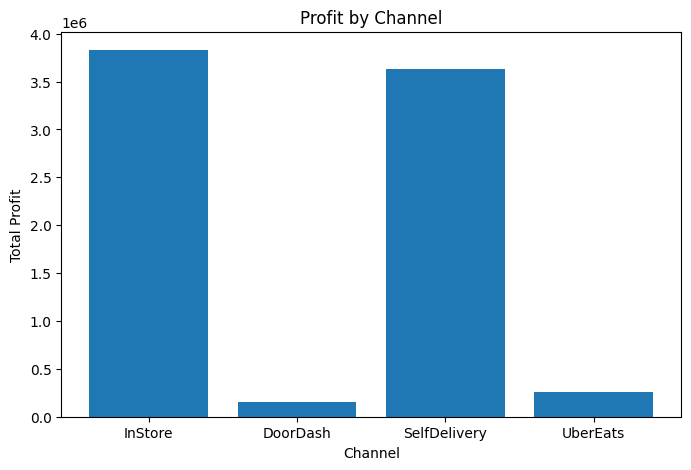

In [15]:
plt.figure(figsize=(8,5))

plt.bar(profit.keys(), profit.values())

plt.title("Profit by Channel")

plt.xlabel("Channel")

plt.ylabel("Total Profit")

plt.show()

In [16]:
df["InStoreProfitPerOrder"] = df["InStoreNetProfit"] / df["InStoreOrders"]

df["UberProfitPerOrder"] = df["UberEatsNetProfit"] / df["UberEatsOrders"]

df["DDProfitPerOrder"] = df["DoorDashNetProfit"] / df["DoorDashOrders"]

df["SDProfitPerOrder"] = df["SelfDeliveryNetProfit"] / df["SelfDeliveryOrders"]

In [17]:
df[[
"InStoreProfitPerOrder",
"UberProfitPerOrder",
"DDProfitPerOrder",
"SDProfitPerOrder"
]].head()

,InStoreProfitPerOrder,UberProfitPerOrder,DDProfitPerOrder,SDProfitPerOrder
0,18.691066,6.379481,6.379492,15.441064
1,13.921699,2.595689,2.595709,9.201711
2,14.906393,2.897393,2.897383,11.656397
3,11.787130,-0.185256,-0.185253,10.897154
4,11.850920,0.518739,0.518719,9.190928


In [18]:
df["InStoreMargin"] = df["InStoreNetProfit"] / df["InStoreRevenue"]

df["UberMargin"] = df["UberEatsNetProfit"] / df["UberEatsRevenue"]

df["DDMargin"] = df["DoorDashNetProfit"] / df["DoorDashRevenue"]

df["SDMargin"] = df["SelfDeliveryNetProfit"] / df["SelfDeliveryRevenue"]

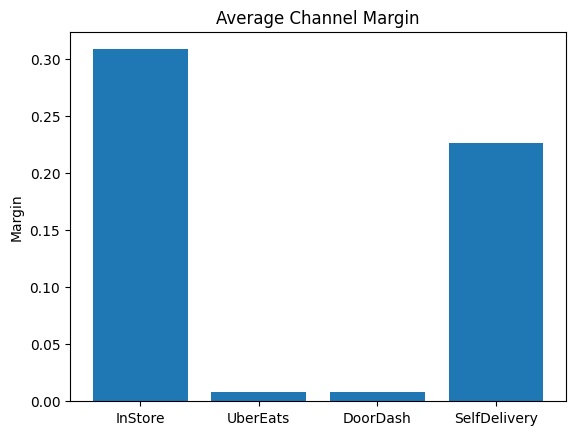

In [19]:
margins = [
    df["InStoreMargin"].mean(),
    df["UberMargin"].mean(),
    df["DDMargin"].mean(),
    df["SDMargin"].mean()
]

channels = ["InStore","UberEats","DoorDash","SelfDelivery"]

plt.bar(channels, margins)

plt.title("Average Channel Margin")

plt.ylabel("Margin")

plt.show()

In [20]:
cuisine_profit = df.groupby("CuisineType")[[
"InStoreNetProfit",
"UberEatsNetProfit",
"DoorDashNetProfit",
"SelfDeliveryNetProfit"
]].sum()

cuisine_profit

,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit
CuisineType,,,,
Burgers,1202800.01,83361.13,46346.03,995186.31
Chicken Dishes,440012.53,-35765.39,-14893.03,169033.53
Chinese,462406.27,45813.13,22868.40,481030.47
Indian,446694.48,80152.74,48049.03,556305.68
Japanese,187066.94,55893.62,30483.17,168931.23
Kebabs/Mediterranean,220253.75,-26860.92,-14687.22,188415.57
Pizza,706807.79,20591.05,11775.35,860703.56
Thai,162375.59,35302.72,21180.52,208672.09


In [21]:
segment_profit = df.groupby("Segment")[[
"InStoreNetProfit",
"UberEatsNetProfit",
"DoorDashNetProfit",
"SelfDeliveryNetProfit"
]].sum()

segment_profit

,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit
Segment,,,,
Cafe,1575843.13,560847.57,307279.92,1326729.78
Full-service,722608.30,-1424668.75,-770900.72,171183.34
Ghost Kitchen,226175.45,547773.19,301233.39,707884.43
QSR,1303790.48,574536.07,313509.66,1422480.89


In [22]:
df["CommissionCost"] = (
df["UberEatsRevenue"] * df["CommissionRate"] +
df["DoorDashRevenue"] * df["CommissionRate"]
)

df["CommissionCost"].sum()

np.float64(14294922.017)

In [23]:
df["SelfDeliveryROI"] = df["SelfDeliveryNetProfit"] / df["SD_DeliveryTotalCost"]

df["SelfDeliveryROI"].mean()

np.float64(3.974776421696509)

In [24]:
df["ProfitVolatility"] = df[[
"InStoreMargin",
"UberMargin",
"DDMargin",
"SDMargin"
]].std(axis=1)

df["ProfitVolatility"].mean()

np.float64(0.1543282801880269)

In [25]:
df["BestChannel"] = df[[
"InStoreNetProfit",
"UberEatsNetProfit",
"DoorDashNetProfit",
"SelfDeliveryNetProfit"
]].idxmax(axis=1)

df["BestChannel"].value_counts()

,count
BestChannel,
InStoreNetProfit,928
SelfDeliveryNetProfit,641
UberEatsNetProfit,127


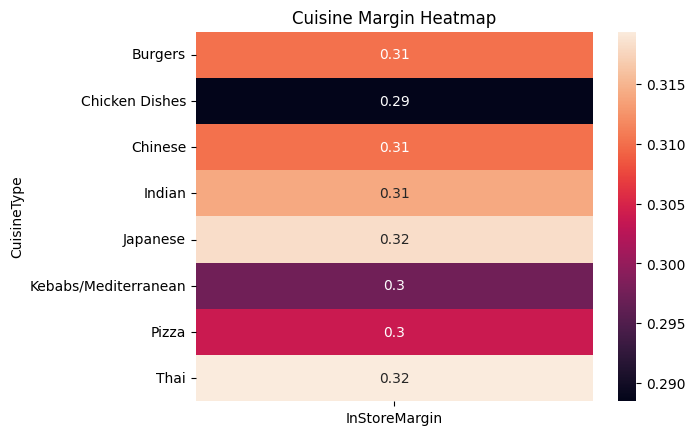

In [26]:
heatmap_data = df.pivot_table(
values="InStoreMargin",
index="CuisineType",
aggfunc="mean"
)

sns.heatmap(heatmap_data, annot=True)

plt.title("Cuisine Margin Heatmap")

plt.show()

In [27]:
df.to_csv("cleaned_restaurant_data.csv", index=False)